# CS610 Group 9: Hidden Linkage & Identity Resolution
**Focus:** TF-IDF Char N-gram Embeddings + GraphSAGE/GCN Link Prediction + POLE Network

---
### Import Dependencies
Importing deep learning frameworks, PyTorch Geometric for our GNNs, and `scikit-learn` for TF-IDF based Identity Resolution.

In [1]:
# !pip install torch torchvision torchaudio torch-geometric pandas networkx scikit-learn matplotlib

import json
import ast
import pickle
import torch
import os
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.utils import from_networkx
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv, SAGEConv

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Set random seed for reproducibility
torch.manual_seed(42)

---
### Load Data & Generate TF-IDF Embeddings
Primary source is `crime_analysis_results_aft_transformer_ner.csv` (fallback: `crime_analysis_results_bart_ner.csv`, then `targets.nested.json`). We aggregate one row per fugitive, keep country + crime-type sets for graph linkage, and apply **TF-IDF char n-gram (2-4)** with L2 normalization on names. These vectors become node features (`x`) for the GNN models.



In [2]:
def build_name_embeddings(names: pd.Series):
    """Pillar 1 logic: char TF-IDF (2-4 gram) + L2 normalization."""
    vec = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),
        max_features=5000,
        sublinear_tf=True
    )
    mat = vec.fit_transform(names.str.upper().astype(str))
    return normalize(mat), vec


def _clean_set(values):
    out = set()
    for v in values:
        if pd.isna(v):
            continue
        s = str(v).strip().lower()
        if s:
            out.add(s)
    return out


def _first_valid(series, default=np.nan):
    for val in series:
        if pd.notna(val):
            return val
    return default


csv_candidates = [
    'crime_analysis_results_aft_transformer_ner.csv',
    'crime_analysis_results_bart_ner.csv'
]

records = []
source_mode = None
fugitive_rows = []

for csv_path in csv_candidates:
    if not os.path.exists(csv_path):
        continue

    df_raw = pd.read_csv(csv_path)
    required_cols = {'id', 'name', 'Code', 'detected_crime_type'}
    if not required_cols.issubset(df_raw.columns):
        continue

    source_mode = 'csv'
    source_path = csv_path

    df_raw = df_raw.dropna(subset=['id', 'name']).copy()
    grouped = df_raw.groupby('id', as_index=False).agg(
        name=('name', 'first'),
        GENDER=('GENDER', 'first') if 'GENDER' in df_raw.columns else ('name', 'first'),
        age_today=('age_today', 'first') if 'age_today' in df_raw.columns else ('name', 'first'),
        height=('height', 'first') if 'height' in df_raw.columns else ('name', 'first'),
        eyeColor=('eyeColor', 'first') if 'eyeColor' in df_raw.columns else ('name', 'first'),
        hairColor=('hairColor', 'first') if 'hairColor' in df_raw.columns else ('name', 'first'),
        sanctions_clean=('sanctions_clean', 'first') if 'sanctions_clean' in df_raw.columns else ('name', 'first')
    )

    if 'GENDER' not in df_raw.columns:
        grouped['GENDER'] = np.nan
    if 'age_today' not in df_raw.columns:
        grouped['age_today'] = np.nan
    if 'height' not in df_raw.columns:
        grouped['height'] = np.nan
    if 'eyeColor' not in df_raw.columns:
        grouped['eyeColor'] = np.nan
    if 'hairColor' not in df_raw.columns:
        grouped['hairColor'] = np.nan
    if 'sanctions_clean' not in df_raw.columns:
        grouped['sanctions_clean'] = np.nan

    countries = df_raw.groupby('id')['Code'].apply(_clean_set)
    topics = df_raw.groupby('id')['detected_crime_type'].apply(_clean_set)

    grouped['countries_set'] = grouped['id'].map(countries).apply(lambda x: x if isinstance(x, set) else set())
    grouped['topics_set'] = grouped['id'].map(topics).apply(lambda x: x if isinstance(x, set) else set())
    grouped['detected_crime_type'] = grouped['id'].map(
        df_raw.groupby('id')['detected_crime_type'].apply(lambda s: _first_valid(s, default=np.nan))
    )

    fugitive_rows = grouped.to_dict('records')
    print(f"Loaded {len(fugitive_rows)} fugitives from CSV: {source_path}")
    break

if source_mode is None:
    base_csv = 'crime_analysis_results.csv'
    if os.path.exists(base_csv):
        print("WARNING: 'crime_analysis_results.csv' found but it has no 'detected_crime_type'.")
        print("         Using JSON fallback for graph construction. Prefer AFT/BART CSV outputs.")

    json_path = 'targets.nested.json'
    if not os.path.exists(json_path):
        raise FileNotFoundError("No valid AFT/BART CSV and no targets.nested.json fallback found.")

    source_mode = 'json'
    source_path = json_path

    with open(json_path, 'r', encoding='utf-8') as f:
        for line in f:
            rec = json.loads(line)
            records.append(rec)

    for rec in records:
        node_id = rec.get('id')
        if not node_id:
            continue

        props = rec.get('properties', {})
        sanctions_arr = props.get('sanctions', [])
        sanctions_reason = np.nan
        if sanctions_arr and isinstance(sanctions_arr, list):
            reasons = sanctions_arr[0].get('properties', {}).get('reason', [])
            if reasons:
                sanctions_reason = '; '.join(reasons)

        bdate = (props.get('birthDate') or [None])[0]
        age_today = np.nan
        if bdate:
            try:
                age_today = int((pd.Timestamp.today() - pd.to_datetime(bdate)).days / 365.25)
            except Exception:
                age_today = np.nan

        topics_set = _clean_set(props.get('topics', []))
        fugitive_rows.append({
            'id': node_id,
            'name': rec.get('caption', 'Unknown'),
            'GENDER': (props.get('gender') or [np.nan])[0],
            'age_today': age_today,
            'height': (props.get('height') or [np.nan])[0],
            'eyeColor': (props.get('eyeColor') or [np.nan])[0],
            'hairColor': (props.get('hairColor') or [np.nan])[0],
            'sanctions_clean': sanctions_reason,
            'detected_crime_type': next(iter(topics_set), np.nan),
            'countries_set': _clean_set(props.get('country', [])),
            'topics_set': topics_set,
        })

    print(f"Loaded {len(fugitive_rows)} fugitives from JSON fallback: {source_path}")


df_fugitives = pd.DataFrame(fugitive_rows).drop_duplicates(subset=['id']).reset_index(drop=True)
df_names = df_fugitives[['id', 'name']].copy()
node_ids = df_names['id'].tolist()

node_to_countries = {
    row['id']: (row['countries_set'] if isinstance(row['countries_set'], set) else set())
    for _, row in df_fugitives.iterrows()
}
node_to_topics = {
    row['id']: (row['topics_set'] if isinstance(row['topics_set'], set) else set())
    for _, row in df_fugitives.iterrows()
}

print("Generating TF-IDF embeddings for node features...")
name_embeddings, name_vectorizer = build_name_embeddings(df_names['name'])

node_features = {}
for i, node_id in enumerate(node_ids):
    node_features[node_id] = torch.tensor(
        name_embeddings[i].toarray().squeeze(),
        dtype=torch.float
    )

feature_dim = name_embeddings.shape[1]
print(f"Node embeddings generated successfully from {source_mode.upper()} source!")

Loaded 6434 fugitives from CSV: crime_analysis_results_aft_transformer_ner.csv
Generating TF-IDF embeddings for node features...
Node embeddings generated successfully from CSV source!


---
### Pillar 1 Diagnostics (TF-IDF Identity Resolution)
This section mirrors the Pillar 1 reporting style from `CS610_Project.ipynb`: null checks, sample query matching, confidence thresholds, and top-3 candidate display.

In [3]:
# =============================================================================
# SECTION 2 — PILLAR 1: TF-IDF CHAR N-GRAM IDENTITY RESOLUTION
# =============================================================================
print("\n" + "─" * 65)
print("  PILLAR 1 — TF-IDF CHAR N-GRAM: IDENTITY RESOLUTION  (weight: 40%)")
print("─" * 65)

def build_name_embeddings(names: pd.Series):
    """
    Char-level TF-IDF (2-4 gram) + L2 normalisation.
    Character n-grams chosen over sentence embeddings (SBERT) as they
    provide superior sub-word sensitivity for AML name screening —
    handling transliterations, abbreviations, and reversed name orders.
    """
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                          max_features=5000, sublinear_tf=True)
    mat = vec.fit_transform(names.str.upper().astype(str))
    return normalize(mat), vec

def query_tfidf(client_name: str, vectorizer, db_embeddings) -> np.ndarray:
    """
    Return cosine similarity array of shape (n_fugitives,).
    Called at inference time — pass result as tfidf_name_score into Pillar 3.
    """
    q = normalize(vectorizer.transform([client_name.upper()]))
    return cosine_similarity(q, db_embeddings)[0]

print("\n⚙  Building name embeddings...")
name_embeddings, name_vectorizer = build_name_embeddings(df_names['name'])
print(f"   Shape: {name_embeddings.shape}")

# Build lightweight profile dataframe for null checks
# Uses the same canonical table (`df_fugitives`) regardless of CSV/JSON source.
df_p1 = df_fugitives[['name', 'GENDER', 'age_today', 'height', 'eyeColor',
                      'hairColor', 'sanctions_clean', 'detected_crime_type']].copy()

# ── Missing value report before modelling ─────────────────────────────────────
print("\n   ── Pre-modelling null check ──────────────────────────────")
key_cols = ['name', 'GENDER', 'age_today', 'height', 'eyeColor', 'hairColor',
            'sanctions_clean', 'detected_crime_type']
for col in key_cols:
    if col in df_p1.columns:
        n_null = df_p1[col].isnull().sum()
        pct    = n_null / len(df_p1) * 100
        flag   = "  ⚠️" if pct > 10 else ""
        print(f"   {col:<22} null: {n_null:>5} ({pct:>5.1f}%){flag}")
print("   ─────────────────────────────────────────────────────────")

# ── Demo queries ──────────────────────────────────────────────────────────────
QUERIES = [
    ("S. Nikitenko",     "Initial + surname"),
    ("Hasen Aksema",     "Missing middle name"),
    ("Abdul Sambolotov", "Single char typo"),
    ("JIAN XIA",         "Exact match"),
    ("Norbert Bialas",   "Case mismatch"),
    ("Ramazan Chigayev", "Transliteration variant"),
    ("M. Al-Saeed",      "Abbreviated first name"),
    ("Levitan Elyasov",  "Cross-script: и→i, я→ya"),
]

p1_results = []
print(f"\n  {'Client Name':<26} {'Top Match':<28} {'Score':>7}  Flag")
print("  " + "─" * 72)

for client_name, desc in QUERIES:
    sims     = query_tfidf(client_name, name_vectorizer, name_embeddings)
    top_idx  = int(np.argmax(sims))
    top_name = df_names.iloc[top_idx]['name']
    top_sc   = float(sims[top_idx])
    top3     = [(df_names.iloc[i]['name'], round(float(sims[i]), 4))
                for i in np.argsort(sims)[::-1][:3]]
    flag = ("🔴 HIGH CONF" if top_sc >= 0.75
            else "🟡 REVIEW"  if top_sc >= 0.50
            else "✅ LOW")
    p1_results.append(dict(client_name=client_name, description=desc,
                           top_match=top_name, tfidf_name_score=top_sc,
                           top3=top3, top_idx=top_idx, flag=flag))
    print(f"  {client_name:<26} {top_name:<28} {top_sc:>7.4f}  {flag}")

print(f"\n  Thresholds (Pillar 1, 40% weight):")
print(f"  ≥ 0.90  Critical  | 0.75–0.90  High | 0.50–0.75  Review | <0.50  Low")

# ── Top-3 detail for each query ───────────────────────────────────────────────
print(f"\n  Top-3 Candidates per Query:")
print(f"  {'Client':<26} {'Rank':<5} {'Match':<28} {'Score':>7}")
print("  " + "─" * 70)
for r in p1_results:
    for rank, (name, sc) in enumerate(r['top3'], 1):
        color_flag = "🔴" if sc >= 0.75 else "🟡" if sc >= 0.50 else "  "
        if rank == 1:
            print(f"  {r['client_name']:<26} #{rank:<4} {name:<28} {sc:>7.4f} {color_flag}")
        else:
            print(f"  {'':26} #{rank:<4} {name:<28} {sc:>7.4f} {color_flag}")
    print("  " + "·" * 70)


─────────────────────────────────────────────────────────────────
  PILLAR 1 — TF-IDF CHAR N-GRAM: IDENTITY RESOLUTION  (weight: 40%)
─────────────────────────────────────────────────────────────────

⚙  Building name embeddings...
   Shape: (6434, 5000)

   ── Pre-modelling null check ──────────────────────────────
   name                   null:     0 (  0.0%)
   GENDER                 null:     4 (  0.1%)
   age_today              null:     0 (  0.0%)
   height                 null:  3495 ( 54.3%)  ⚠️
   eyeColor               null:  3733 ( 58.0%)  ⚠️
   hairColor              null:  3415 ( 53.1%)  ⚠️
   sanctions_clean        null:     2 (  0.0%)
   detected_crime_type    null:     0 (  0.0%)
   ─────────────────────────────────────────────────────────

  Client Name                Top Match                      Score  Flag
  ────────────────────────────────────────────────────────────────────────
  S. Nikitenko               SANAVBARI NIKITENKO           0.7404  🟡 REVIEW
  Hasen 

---
### Build the Rich Graph Structure
We construct a `NetworkX` graph where an edge (Hidden Linkage) is added only if two fugitives share **at least one country (`Code`) AND at least one detected crime type**. This avoids overly generic `topics` values from the raw JSON feed.



In [4]:
G = nx.Graph()

# Add Nodes with TF-IDF embeddings
for node_id, embedding in node_features.items():
    G.add_node(node_id, x=embedding)

# Add Edges based on shared Country AND shared Crime Type
for i in range(len(node_ids)):
    id1 = node_ids[i]
    c1 = node_to_countries.get(id1, set())
    t1 = node_to_topics.get(id1, set())

    if not c1 or not t1:
        continue

    for j in range(i + 1, len(node_ids)):
        id2 = node_ids[j]
        c2 = node_to_countries.get(id2, set())
        t2 = node_to_topics.get(id2, set())

        if not c2 or not t2:
            continue

        if (c1 & c2) and (t1 & t2):
            G.add_edge(id1, id2)

print(f"Graph built with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph built with 6434 nodes and 1931646 edges.


---
### PyG Conversion & Data Splitting
Convert the graph to a **PyTorch Geometric (PyG)** Data object. We use `RandomLinkSplit` to hide 30% of the edges to evaluate our models' ability to predict them.

In [5]:
pyg_data = from_networkx(G)

# Ensure dense feature matrix ordering aligns with node_ids used in the NetworkX graph.
ordered_nodes = list(G.nodes())
pyg_data.x = torch.stack([G.nodes[n]['x'] for n in ordered_nodes], dim=0)

transform = T.RandomLinkSplit(
    num_val=0.15, num_test=0.15, is_undirected=True, add_negative_train_samples=True
)
train_data, val_data, test_data = transform(pyg_data)
print("Data splits (Train: 70%, Val: 15%, Test: 15%) created successfully!")

Data splits (Train: 70%, Val: 15%, Test: 15%) created successfully!


---
### Define GCN and GraphSAGE Architectures
Both models will take our TF-IDF char n-gram text embeddings and pass them through graph convolution layers to predict the likelihood of hidden criminal linkages.



In [6]:
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def encode(self, x, edge_index): return self.conv2(self.conv1(x, edge_index).relu(), edge_index)
    def decode(self, z, edge_label_index): return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)
    def forward(self, x, edge_index, edge_label_index): return self.decode(self.encode(x, edge_index), edge_label_index)

class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
    def encode(self, x, edge_index): return self.conv2(self.conv1(x, edge_index).relu(), edge_index)
    def decode(self, z, edge_label_index): return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)
    def forward(self, x, edge_index, edge_label_index): return self.decode(self.encode(x, edge_index), edge_label_index)

gcn_model = GCNLinkPredictor(feature_dim, 128, 32)
sage_model = SAGELinkPredictor(feature_dim, 128, 32)
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=0.01)
optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

---
### Train & Evaluate (AUC, Recall, & Hits@K)
We evaluate our Link Prediction using the **AUC** metric (industry standard), **Recall** (to measure the proportion of true criminal linkages successfully identified above a 0.5 threshold), and **Hits@K** (measuring if true linkages rank higher than randomly generated false linkages). Progress is reported every 10 epochs.

In [7]:
from sklearn.metrics import roc_auc_score, recall_score


def train(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_label_index)
    loss = criterion(out, data.edge_label.float())
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def test_metrics(model, data, k_list=[10, 50, 100]):
    model.eval()
    out = model(data.x, data.edge_index, data.edge_label_index)
    preds = torch.sigmoid(out).cpu().numpy()
    targets = data.edge_label.cpu().numpy()

    # Guard against single-class splits in AUC.
    if len(np.unique(targets)) < 2:
        auc = float('nan')
    else:
        auc = roc_auc_score(targets, preds)

    recall = recall_score(targets, (preds >= 0.5).astype(int), zero_division=0)

    pos_preds = preds[targets == 1]
    neg_preds = preds[targets == 0]
    results = {'AUC': auc, 'Recall': recall}

    for k in k_list:
        if len(pos_preds) == 0:
            results[f'Hits@{k}'] = 0.0
            continue
        hits = 0
        for pos_score in pos_preds:
            rank = (neg_preds > pos_score).sum() + 1
            if rank <= k:
                hits += 1
        results[f'Hits@{k}'] = hits / len(pos_preds)
    return results


print("--- Training GraphSAGE ---")
for epoch in range(1, 101):
    loss = train(sage_model, optimizer_sage, train_data)
    if epoch % 10 == 0:
        val_res = test_metrics(sage_model, val_data, k_list=[10, 50, 100])
        print(f"Epoch: {epoch:03d} | Train Loss: {loss:.4f} | Val AUC: {val_res['AUC']:.4f} | Val Recall: {val_res['Recall']:.4f} | "
              f"Hits@10: {val_res['Hits@10']:.4f} | Hits@50: {val_res['Hits@50']:.4f} | Hits@100: {val_res['Hits@100']:.4f}")

test_res_sage = test_metrics(sage_model, test_data, k_list=[10, 50, 100])
print(f"\nGraphSAGE Final Test -> AUC: {test_res_sage['AUC']:.4f} | Recall: {test_res_sage['Recall']:.4f} | "
      f"Hits@10: {test_res_sage['Hits@10']:.4f} | Hits@50: {test_res_sage['Hits@50']:.4f} | Hits@100: {test_res_sage['Hits@100']:.4f}\n")

print("--- Training GCN ---")
for epoch in range(1, 101):
    loss = train(gcn_model, optimizer_gcn, train_data)
    if epoch % 10 == 0:
        val_res = test_metrics(gcn_model, val_data, k_list=[10, 50, 100])
        print(f"Epoch: {epoch:03d} | Train Loss: {loss:.4f} | Val AUC: {val_res['AUC']:.4f} | Val Recall: {val_res['Recall']:.4f} | "
              f"Hits@10: {val_res['Hits@10']:.4f} | Hits@50: {val_res['Hits@50']:.4f} | Hits@100: {val_res['Hits@100']:.4f}")

test_res_gcn = test_metrics(gcn_model, test_data, k_list=[10, 50, 100])
print(f"\nGCN Final Test       -> AUC: {test_res_gcn['AUC']:.4f} | Recall: {test_res_gcn['Recall']:.4f} | "
      f"Hits@10: {test_res_gcn['Hits@10']:.4f} | Hits@50: {test_res_gcn['Hits@50']:.4f} | Hits@100: {test_res_gcn['Hits@100']:.4f}")


@torch.no_grad()
def compute_linkage_scores(model, graph_data, graph_nx, node_order):
    model.eval()
    z = model.encode(graph_data.x, graph_data.edge_index)
    node_to_idx = {nid: idx for idx, nid in enumerate(node_order)}

    rows = []
    for node_id in node_order:
        idx = node_to_idx[node_id]
        neighbor_ids = [n for n in graph_nx.neighbors(node_id) if n in node_to_idx]
        if not neighbor_ids:
            linkage_score = 0.0
        else:
            nbr_idx = torch.tensor([node_to_idx[n] for n in neighbor_ids], dtype=torch.long)
            logits = (z[idx] * z[nbr_idx]).sum(dim=-1)
            probs = torch.sigmoid(logits)
            linkage_score = float(probs.mean().item())

        rows.append({
            'id': node_id,
            'name': df_names.loc[df_names['id'] == node_id, 'name'].iloc[0],
            'linkage_score': round(linkage_score, 6)
        })

    return pd.DataFrame(rows)


# -------------------------
# Persist outputs and models
# -------------------------
OUTPUT_DIR = Path('outputs')
MODEL_DIR = OUTPUT_DIR / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Export linkage scores (GraphSAGE default for Pillar 4 output)
linkage_scores_df = compute_linkage_scores(sage_model, pyg_data, G, ordered_nodes)
linkage_scores_path = OUTPUT_DIR / 'hidden_linkage_scores.csv'
linkage_scores_df.to_csv(linkage_scores_path, index=False)
print(f"Saved linkage scores to: {linkage_scores_path}")

# Save model payloads as pickle files
sage_payload = {
    'model_name': 'GraphSAGE',
    'state_dict': {k: v.detach().cpu() for k, v in sage_model.state_dict().items()},
    'model_config': {'in_channels': feature_dim, 'hidden_channels': 128, 'out_channels': 32},
    'test_metrics': test_res_sage,
}

gcn_payload = {
    'model_name': 'GCN',
    'state_dict': {k: v.detach().cpu() for k, v in gcn_model.state_dict().items()},
    'model_config': {'in_channels': feature_dim, 'hidden_channels': 128, 'out_channels': 32},
    'test_metrics': test_res_gcn,
}

meta_payload = {
    'node_order': ordered_nodes,
    'node_id_to_index': {nid: idx for idx, nid in enumerate(ordered_nodes)},
    'feature_dim': feature_dim,
    'tfidf_settings': {
        'analyzer': 'char_wb',
        'ngram_range': (2, 4),
        'max_features': 5000,
        'sublinear_tf': True,
    },
    'vectorizer': name_vectorizer,
    'data_source': source_path,
    'source_mode': source_mode,
}

with open(MODEL_DIR / 'graphsage_link_predictor.pkl', 'wb') as f:
    pickle.dump(sage_payload, f)
with open(MODEL_DIR / 'gcn_link_predictor.pkl', 'wb') as f:
    pickle.dump(gcn_payload, f)
with open(MODEL_DIR / 'linkage_inference_meta.pkl', 'wb') as f:
    pickle.dump(meta_payload, f)

print(f"Saved model pickle artifacts in: {MODEL_DIR}")

--- Training GraphSAGE ---
Epoch: 010 | Train Loss: 0.4881 | Val AUC: 0.9436 | Val Recall: 0.9987 | Hits@10: 0.0019 | Hits@50: 0.0108 | Hits@100: 0.0179
Epoch: 020 | Train Loss: 0.4461 | Val AUC: 0.9501 | Val Recall: 0.9998 | Hits@10: 0.0543 | Hits@50: 0.0895 | Hits@100: 0.1144
Epoch: 030 | Train Loss: 0.4359 | Val AUC: 0.9513 | Val Recall: 0.9998 | Hits@10: 0.1758 | Hits@50: 0.2338 | Hits@100: 0.2728
Epoch: 040 | Train Loss: 0.4295 | Val AUC: 0.9519 | Val Recall: 0.9997 | Hits@10: 0.2791 | Hits@50: 0.3324 | Hits@100: 0.3620
Epoch: 050 | Train Loss: 0.4267 | Val AUC: 0.9521 | Val Recall: 0.9995 | Hits@10: 0.3392 | Hits@50: 0.4040 | Hits@100: 0.4286
Epoch: 060 | Train Loss: 0.4240 | Val AUC: 0.9525 | Val Recall: 0.9995 | Hits@10: 0.4594 | Hits@50: 0.4905 | Hits@100: 0.5006
Epoch: 070 | Train Loss: 0.4097 | Val AUC: 0.9711 | Val Recall: 0.9995 | Hits@10: 0.5325 | Hits@50: 0.5345 | Hits@100: 0.5348
Epoch: 080 | Train Loss: 0.2790 | Val AUC: 0.9962 | Val Recall: 0.9999 | Hits@10: 0.4119 | 

---
### Ego-Graph Visualization Tool
This function isolates a single fugitive and plots a "Spider Web" of their immediate hidden connections.



Plotting 1234 hidden connections for SANAVBARI NIKITENKO...


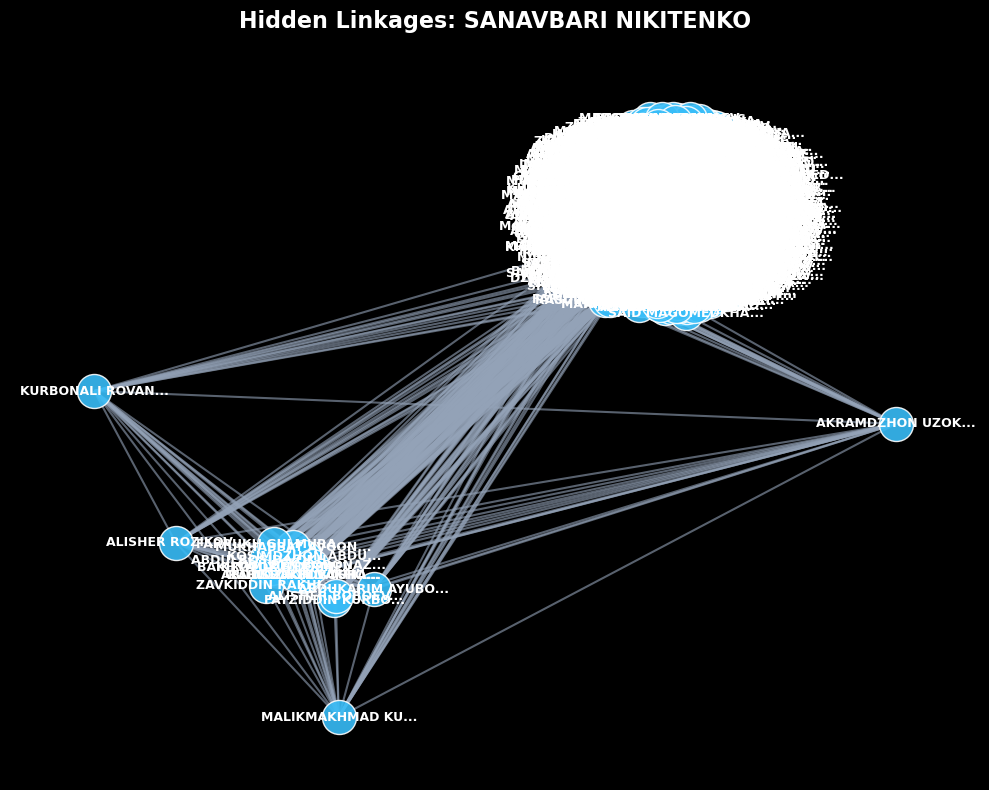

In [8]:
def plot_fugitive_network(query, df, G_net, radius=1):
    target_id, target_name = None, None
    
    if query in df['id'].values:
        target_id = query
        target_name = df[df['id'] == query]['name'].iloc[0]
    else:
        matches = df[df['name'].str.contains(query, case=False, na=False)]
        if matches.empty: return print(f"X No fugitive found matching: '{query}'")
        target_id, target_name = matches.iloc[0]['id'], matches.iloc[0]['name']
        
    if target_id not in G_net.nodes(): return print(f"WARNING: {target_name} has no hidden linkages (Isolated).")
        
    subgraph = nx.ego_graph(G_net, target_id, radius=radius)
    if subgraph.number_of_nodes() <= 1: return print(f"WARNING: {target_name} is in the graph but currently has no shared connections.")
    
    print(f"Plotting {subgraph.number_of_nodes() - 1} hidden connections for {target_name}...")
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(subgraph, seed=42, k=0.5)
    
    neighbors = [n for n in subgraph.nodes() if n != target_id]
    nx.draw_networkx_nodes(subgraph, pos, nodelist=neighbors, node_color='#38bdf8', node_size=600, edgecolors='white', alpha=0.9)
    nx.draw_networkx_nodes(subgraph, pos, nodelist=[target_id], node_color='#ff2d2d', node_size=1200, edgecolors='white')
    nx.draw_networkx_edges(subgraph, pos, alpha=0.6, edge_color='#94a3b8', width=1.5)
    
    id_to_name = dict(zip(df['id'], df['name']))
    labels = {n: id_to_name.get(n, str(n))[:15] + "..." for n in subgraph.nodes()}
    
    nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=9, font_weight='bold', font_color='white')
    plt.title(f"Hidden Linkages: {target_name}", fontsize=16, fontweight='bold', color='white', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Run a test visualization
plot_fugitive_network("SANAVBARI NIKITENKO", df_names, G)

---
### POLE Framework Network Analysis
Using the **POLE (Persons, Objects, Locations, Events)** framework, we parse the NER entities generated by the pipeline to turn flat rows into a dense intelligence web. 

**Legend Mapping:**
* **Persons:** Red (`PERSON`)
* **Objects:** Yellow (`ORG` / Assests)
* **Locations:** Teal (`GPE`)
* **Events:** Grey (`CASE` / Incidents)

This visualizes how different entities intersect across multiple fugitive case files.



Rows with entities for POLE processing: 1,357 / 7,012
POLE Graph: 2,499 nodes, 2,589 edges
Removed 59 hub nodes (degree > 5)


c:\Users\kaiba\anaconda3\envs\pytorch_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


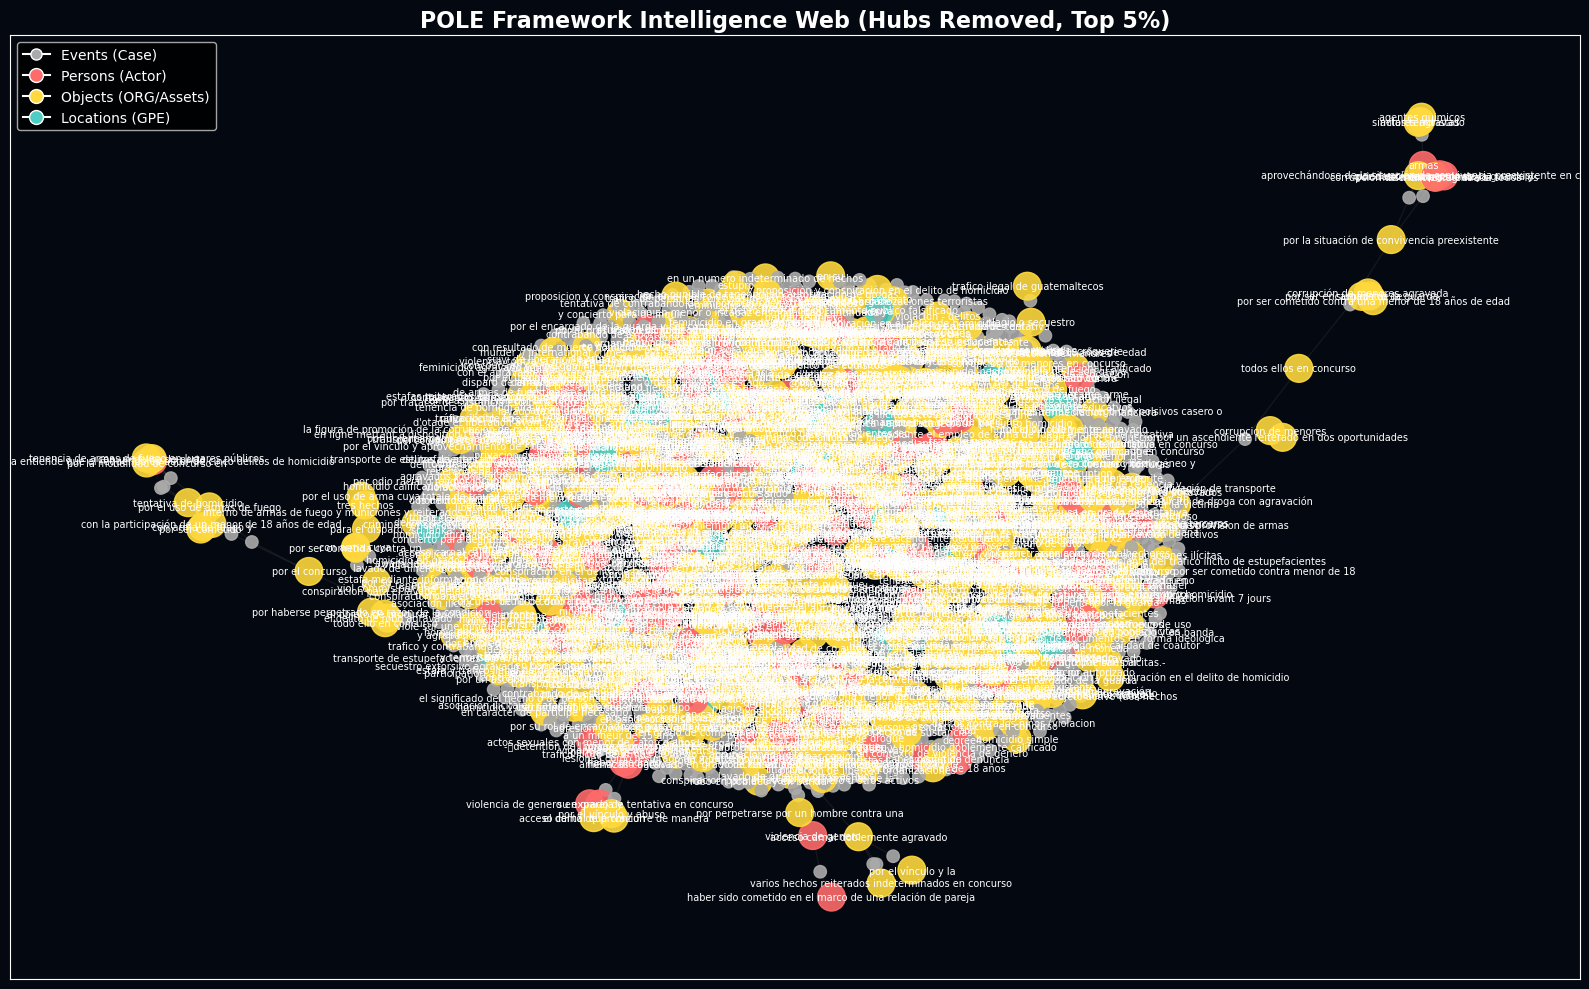


POLE Centrality Analysis — Top 10 Key Entities:
  [Object  ] trafico ilicito                0.0021
  [Location] iraq                           0.0021
  [Object  ] asesinato                      0.0021
  [Object  ] commis en bande                0.0021
  [Object  ] trata de personas              0.0021
  [Object  ] por el uso de arma de fuego en concurso 0.0021
  [Person  ] secuestro extorsivo            0.0021
  [Object  ] infracción                     0.0021
  [Person  ] la situación de convivencia    0.0021
  [Object  ] y conspiracion en el delito de homicidio 0.0021

POLE Entity Breakdown:
  Object   (ORG   ) : 821 nodes
  Person   (PERSON) : 212 nodes
  Location (GPE   ) : 50 nodes


In [9]:
# Load the dataset with extracted entities
try:
    df_ready = pd.read_csv('crime_analysis_results_aft_transformer_ner.csv')
except FileNotFoundError:
    print("WARNING: Please ensure 'crime_analysis_results_aft_transformer_ner.csv' is in your directory to run POLE.")
    df_ready = pd.DataFrame({'entities': []}) # Fallback empty DF

def safe_parse(val):
    if isinstance(val, list): return val
    try:
        result = ast.literal_eval(str(val))
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

if not df_ready.empty and 'entities' in df_ready.columns:
    df_ready['entities'] = df_ready['entities'].apply(safe_parse)
    df_network = df_ready[df_ready['entities'].apply(lambda x: isinstance(x, list) and len(x) > 0)].copy()
    print(f"Rows with entities for POLE processing: {len(df_network):,} / {len(df_ready):,}")

    # Build POLE Graph
    G_pole = nx.Graph()
    POLE_COLORS = {"PERSON": "#FF6B6B", "ORG": "#FFD93D", "GPE": "#4ECDC4", "CASE": "#AAAAAA"}
    skipped = 0

    for idx, row in df_network.iterrows():
        case_node = f"Event_Case_{idx}"
        G_pole.add_node(case_node, node_type="CASE")

        for entity in row['entities']:
            if isinstance(entity, tuple) and len(entity) == 2:
                ent_text, ent_label = entity[0].strip(), entity[1]
            elif isinstance(entity, str):
                ent_text, ent_label = entity.strip(), "UNKNOWN"
            else:
                skipped += 1
                continue

            if not ent_text:
                skipped += 1
                continue

            G_pole.add_node(ent_text, node_type=ent_label)
            G_pole.add_edge(case_node, ent_text)

    print(f"POLE Graph: {G_pole.number_of_nodes():,} nodes, {G_pole.number_of_edges():,} edges")

    # Prune Hubs
    def prune_hub_nodes(G, percentile=95):
        if G.number_of_nodes() == 0: return G
        degrees = dict(G.degree())
        deg_vals = list(degrees.values())
        threshold = np.percentile(deg_vals, percentile)
        hubs_to_remove = [n for n, deg in degrees.items() if deg > threshold and not str(n).startswith("Event_Case_")]
        
        G_cleaned = G.copy()
        G_cleaned.remove_nodes_from(hubs_to_remove)
        print(f"Removed {len(hubs_to_remove)} hub nodes (degree > {threshold:.0f})")
        return G_cleaned

    G_simple = prune_hub_nodes(G_pole, percentile=95)

    # Node Styling for POLE Framework
    colors, sizes = [], []
    for n in G_simple.nodes():
        ntype = G_simple.nodes[n].get('node_type', 'UNKNOWN')
        if ntype == "CASE":
            colors.append("#AAAAAA")
            sizes.append(80)
        else:
            colors.append(POLE_COLORS.get(ntype, "#CCCCCC"))
            sizes.append(400)

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 10))
    pos = nx.spring_layout(G_simple, k=1.2, seed=42)
    
    nx.draw_networkx_edges(G_simple, pos, ax=ax, alpha=0.2, edge_color="#555555")
    nx.draw_networkx_nodes(G_simple, pos, ax=ax, node_color=colors, node_size=sizes, alpha=0.9)

    entity_nodes = {n: n for n in G_simple.nodes() if not str(n).startswith("Event_Case_")}
    nx.draw_networkx_labels(G_simple, pos, labels=entity_nodes, ax=ax, font_size=7, font_color="white")

    ax.set_title("POLE Framework Intelligence Web (Hubs Removed, Top 5%)", fontsize=16, fontweight='bold', color='white')
    
    # POLE Specific Legend
    legend_elements = [
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA', markersize=8, label='Events (Case)'), 
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FF6B6B', markersize=10, label='Persons (Actor)'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#FFD93D', markersize=10, label='Objects (ORG/Assets)'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4ECDC4', markersize=10, label='Locations (GPE)')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    fig.patch.set_facecolor('#040810')
    ax.set_facecolor('#040810')
    plt.tight_layout()
    plt.show()

    # Degree Centrality Analysis
    print("\nPOLE Centrality Analysis — Top 10 Key Entities:")
    centrality = nx.degree_centrality(G_simple)
    top_degree = sorted([(n, s) for n, s in centrality.items() if not str(n).startswith("Event_Case_")], key=lambda x: x[1], reverse=True)[:10]
    for node, score in top_degree:
        ntype = G_simple.nodes[node].get('node_type', '?')
        pole_type = "Object" if ntype == "ORG" else "Location" if ntype == "GPE" else "Person" if ntype == "PERSON" else "Unknown"
        print(f"  [{pole_type:<8}] {node:<30} {score:.4f}")

    # Breakdown
    print("\nPOLE Entity Breakdown:")
    type_counts = Counter(data.get('node_type', 'UNKNOWN') for n, data in G_simple.nodes(data=True) if not str(n).startswith("Event_Case_"))
    for etype, count in type_counts.most_common():
        pole_type = "Object" if etype == "ORG" else "Location" if etype == "GPE" else "Person" if etype == "PERSON" else "Unknown"
        print(f"  {pole_type:<8} ({etype:<6}) : {count:,} nodes")


---
### Post-Training Validation (Split Balance, Score Distribution, and New Link Inference)
This section validates whether metrics are trustworthy by checking edge-label balance, positive/negative score separation, and a sample of top-K **new** (non-existing) links predicted by the trained model.


In [12]:
# -----------------------------
# Validation utilities
# -----------------------------

def _split_balance(data, name):
    y = data.edge_label.cpu().numpy()
    pos = int((y == 1).sum())
    neg = int((y == 0).sum())
    total = len(y)
    print(f"[{name}] total={total:,} | pos={pos:,} ({pos/total:.2%}) | neg={neg:,} ({neg/total:.2%})")


@torch.no_grad()
def _prediction_distribution(model, data, split_name='test'):
    model.eval()
    logits = model(data.x, data.edge_index, data.edge_label_index)
    probs = torch.sigmoid(logits).cpu().numpy()
    y = data.edge_label.cpu().numpy()

    pos_probs = probs[y == 1]
    neg_probs = probs[y == 0]

    def _summary(arr):
        if len(arr) == 0:
            return {'count': 0, 'min': np.nan, 'p25': np.nan, 'median': np.nan,
                    'mean': np.nan, 'p75': np.nan, 'max': np.nan}
        return {
            'count': len(arr),
            'min': float(np.min(arr)),
            'p25': float(np.percentile(arr, 25)),
            'median': float(np.median(arr)),
            'mean': float(np.mean(arr)),
            'p75': float(np.percentile(arr, 75)),
            'max': float(np.max(arr)),
        }

    print(f"\n[{split_name}] score distribution by class")
    print("  positive edges:", _summary(pos_probs))
    print("  negative edges:", _summary(neg_probs))


@torch.no_grad()
def infer_top_new_links(model, graph_data, graph_nx, node_names_df,
                        node_to_countries_map, node_to_topics_map,
                        anchor_count=10, top_k=3, candidate_cap=500, seed=42):
    """
    Infer top-K new links for sampled anchors.
    Candidate pool is constrained to nodes sharing country OR crime type,
    excluding already-connected neighbors.
    """
    model.eval()
    z = model.encode(graph_data.x, graph_data.edge_index).cpu()

    node_order_local = list(graph_nx.nodes())
    node_to_idx = {nid: i for i, nid in enumerate(node_order_local)}
    id_to_name = dict(zip(node_names_df['id'], node_names_df['name']))

    # Build inverse lookup for candidate generation.
    country_to_nodes = {}
    topic_to_nodes = {}
    for nid in node_order_local:
        for c in node_to_countries_map.get(nid, set()):
            country_to_nodes.setdefault(c, set()).add(nid)
        for t in node_to_topics_map.get(nid, set()):
            topic_to_nodes.setdefault(t, set()).add(nid)

    rng = np.random.default_rng(seed)
    anchors = rng.choice(node_order_local, size=min(anchor_count, len(node_order_local)), replace=False)

    rows = []
    for anchor in anchors:
        anchor_idx = node_to_idx[anchor]
        existing_neighbors = set(graph_nx.neighbors(anchor))
        existing_neighbors.add(anchor)

        cands = set()
        for c in node_to_countries_map.get(anchor, set()):
            cands.update(country_to_nodes.get(c, set()))
        for t in node_to_topics_map.get(anchor, set()):
            cands.update(topic_to_nodes.get(t, set()))

        cands = list(cands - existing_neighbors)
        if not cands:
            continue

        if len(cands) > candidate_cap:
            cands = list(rng.choice(cands, size=candidate_cap, replace=False))

        cand_idx = torch.tensor([node_to_idx[n] for n in cands], dtype=torch.long)
        scores = torch.sigmoid((z[anchor_idx] * z[cand_idx]).sum(dim=-1)).numpy()

        order = np.argsort(scores)[::-1][:top_k]
        for rank_pos, idx_pos in enumerate(order, 1):
            nid = cands[idx_pos]
            rows.append({
                'anchor_id': anchor,
                'anchor_name': id_to_name.get(anchor, anchor),
                'candidate_id': nid,
                'candidate_name': id_to_name.get(nid, nid),
                'predicted_link_score': float(scores[idx_pos]),
                'rank': rank_pos,
            })

    df_new_links = pd.DataFrame(rows).sort_values(['anchor_id', 'rank'])
    return df_new_links


# -----------------------------
# Run validation checks
# -----------------------------
print("=== Split Balance Check ===")
_split_balance(train_data, 'train')
_split_balance(val_data, 'val')
_split_balance(test_data, 'test')

print("\n=== GraphSAGE Score Separation Check ===")
_prediction_distribution(sage_model, test_data, split_name='test (GraphSAGE)')

print("\n=== GCN Score Separation Check ===")
_prediction_distribution(gcn_model, test_data, split_name='test (GCN)')

print("\n=== Top-K New (Non-Neighbor) Link Inference Sample (GraphSAGE) ===")
df_new_links_sample = infer_top_new_links(
    sage_model,
    pyg_data,
    G,
    df_names,
    node_to_countries,
    node_to_topics,
    anchor_count=12,
    top_k=3,
    candidate_cap=500,
    seed=42,
)

if df_new_links_sample.empty:
    print("No new-link candidates found under current constraints.")
else:
    display(df_new_links_sample.head(30))
    out_new_links = Path('outputs') / 'top_new_links_sample.csv'
    df_new_links_sample.to_csv(out_new_links, index=False)
    print(f"Saved sampled new-link inference output to: {out_new_links}")

=== Split Balance Check ===
[train] total=2,704,308 | pos=1,352,154 (50.00%) | neg=1,352,154 (50.00%)
[val] total=579,492 | pos=289,746 (50.00%) | neg=289,746 (50.00%)
[test] total=579,492 | pos=289,746 (50.00%) | neg=289,746 (50.00%)

=== GraphSAGE Score Separation Check ===

[test (GraphSAGE)] score distribution by class
  positive edges: {'count': 289746, 'min': 0.0038675700780004263, 'p25': 1.0, 'median': 1.0, 'mean': 0.9866594076156616, 'p75': 1.0, 'max': 1.0}
  negative edges: {'count': 289746, 'min': 9.702793891144403e-25, 'p25': 0.0416656993329525, 'median': 0.09485174715518951, 'mean': 0.24680933356285095, 'p75': 0.5426473021507263, 'max': 1.0}

=== GCN Score Separation Check ===

[test (GCN)] score distribution by class
  positive edges: {'count': 289746, 'min': 0.01807759515941143, 'p25': 1.0, 'median': 1.0, 'mean': 0.9853942394256592, 'p75': 1.0, 'max': 1.0}
  negative edges: {'count': 289746, 'min': 9.90244851202687e-22, 'p25': 0.0332404300570488, 'median': 0.0597628206014

,anchor_id,anchor_name,candidate_id,candidate_name,predicted_link_score,rank
3,interpol-red-2004-26427,JOSE ANTONIO SOLARES GONZALEZ,interpol-red-2021-11671,OLIMDZHON ATANAZAROV,0.673233,1
4,interpol-red-2004-26427,JOSE ANTONIO SOLARES GONZALEZ,interpol-red-2014-67617,ZHASURBEK ISLAMOV,0.670788,2
5,interpol-red-2004-26427,JOSE ANTONIO SOLARES GONZALEZ,interpol-red-2015-5671,ISLOM BAROTOV,0.658231,3
18,interpol-red-2005-17278,SHYAMAL RAO REDDY,interpol-red-2017-163955,RADZHAB GUMMAEV,0.819378,1
19,interpol-red-2005-17278,SHYAMAL RAO REDDY,interpol-red-2014-72323,BEKBOLOT KYDYRGYCHOV,0.774985,2
20,interpol-red-2005-17278,SHYAMAL RAO REDDY,interpol-red-2011-31616,YURIY YANAKOV,0.771353,3
24,interpol-red-2005-52538,MARLON JAMES WINTERS,interpol-red-2010-6182,RUSLAN NASRETDINOV,0.742105,1
25,interpol-red-2005-52538,MARLON JAMES WINTERS,interpol-red-2023-26311,ALISHER DZHUMAEV,0.700357,2
26,interpol-red-2005-52538,MARLON JAMES WINTERS,interpol-red-2012-324783,ALI HUSSAIN ALHAMOUD,0.697718,3
33,interpol-red-2013-72033,KOSTA BJELOTOMIC,interpol-red-2013-70515,ZAYURBEK ANARBEK UULU,0.785544,1


Saved sampled new-link inference output to: outputs\top_new_links_sample.csv


# Helper: load serialized model + metadata and run quick linkage inference prep.

In [11]:
# Helper: load serialized model + metadata and run quick linkage inference prep.

def load_pickled_linkage_model(model_type='graphsage', model_dir='outputs/models', map_location='cpu'):
    model_dir = Path(model_dir)
    model_type = model_type.lower().strip()

    if model_type not in {'graphsage', 'gcn'}:
        raise ValueError("model_type must be 'graphsage' or 'gcn'.")

    model_file = model_dir / f"{model_type}_link_predictor.pkl"
    meta_file = model_dir / 'linkage_inference_meta.pkl'

    with open(model_file, 'rb') as f:
        payload = pickle.load(f)
    with open(meta_file, 'rb') as f:
        meta = pickle.load(f)

    cfg = payload['model_config']
    if payload['model_name'].lower() == 'graphsage':
        model = SAGELinkPredictor(cfg['in_channels'], cfg['hidden_channels'], cfg['out_channels'])
    else:
        model = GCNLinkPredictor(cfg['in_channels'], cfg['hidden_channels'], cfg['out_channels'])

    state_dict = {k: v.to(map_location) if hasattr(v, 'to') else v
                  for k, v in payload['state_dict'].items()}
    model.load_state_dict(state_dict)
    model.to(map_location)
    model.eval()

    print(f"Loaded {payload['model_name']} from {model_file}")
    return model, meta


# Example usage:
# restored_model, restored_meta = load_pickled_linkage_model('graphsage')